# 04 — Classification (Laptop Purchase Prediction)

**Input:** `data/processed/processed_data.csv` (features + BuyLaptop binary)  
**Output:** `models/laptop_classifier.pkl`

Predict whether a customer will buy a laptop (1 = Yes, 0 = No) using RandomForest.


# Imports

In [12]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split

warnings.filterwarnings('ignore')

PLOT_DIR = Path('../plots/classification')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Read Data

In [13]:

# Load processed data
df = pd.read_csv('../data/processed/processed_data.csv')

# Separate features and target
if 'BuyLaptop' not in df.columns:
    raise ValueError('BuyLaptop column not found in processed_data.csv')

X = df.drop(columns=['BuyLaptop'])
y = df['BuyLaptop']

print(f'Features shape: {X.shape} | Target shape: {y.shape}')
print(f'Target distribution:\n{y.value_counts()}')
print(f'  0 (No): {(y == 0).sum()}, 1 (Yes): {(y == 1).sum()}')


Features shape: (8068, 8) | Target shape: (8068,)
Target distribution:
BuyLaptop
0    6436
1    1632
Name: count, dtype: int64
  0 (No): 6436, 1 (Yes): 1632


## Train-Test Split

In [14]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (6454, 8) | Test: (1614, 8)


# Random-Forest

In [15]:
# Train Random Forest classifier for laptop purchase prediction
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual scores: {cv_scores.round(4)}')

5-Fold CV F1 Score: 0.9969 ± 0.0031
Individual scores: [1.     0.9942 0.9923 1.     0.9981]


# Predict

In [16]:
# Evaluate on test set
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {accuracy:.4f}')
print('\nClassification Report (0=No, 1=Yes):')
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)']))

Test Accuracy: 0.9988

Classification Report (0=No, 1=Yes):
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00      1288
     Yes (1)       1.00      1.00      1.00       326

    accuracy                           1.00      1614
   macro avg       1.00      1.00      1.00      1614
weighted avg       1.00      1.00      1.00      1614



# Confusion matrix

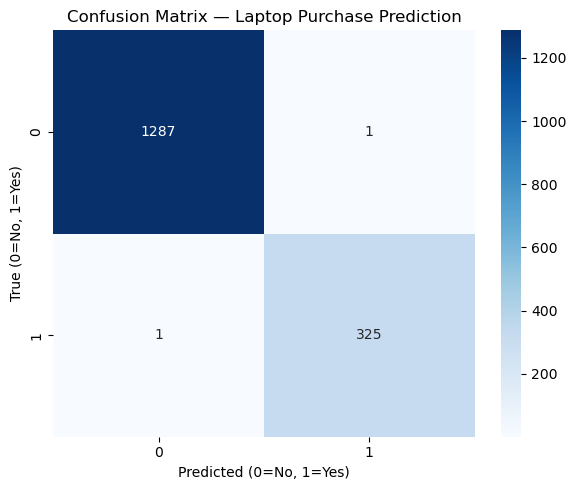

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (0=No, 1=Yes)')
plt.ylabel('True (0=No, 1=Yes)')
plt.title('Confusion Matrix — Laptop Purchase Prediction')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

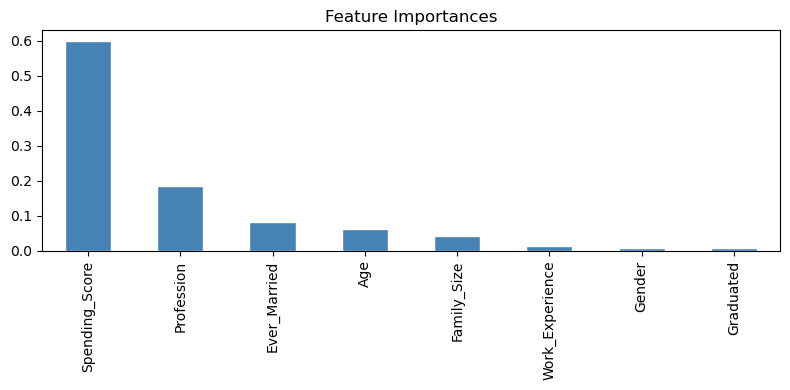

Spending_Score     0.599080
Profession         0.185470
Ever_Married       0.082551
Age                0.062954
Family_Size        0.040675
Work_Experience    0.012162
Gender             0.008949
Graduated          0.008160
dtype: float64


In [18]:
# Feature importance
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_importances.png', dpi=150)
plt.show()
print(importances)

# Save and Test Saved Model

In [19]:
# Save model
with open('../models/laptop_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

print('✓ Saved laptop_classifier.pkl')


✓ Saved laptop_classifier.pkl


# Test Model

In [20]:
# Load saved model and test
with open('../models/laptop_classifier.pkl', 'rb') as f:
    loaded_clf = pickle.load(f)

loaded_y_pred = loaded_clf.predict(X_test)
print(f'\nLoaded Model Test Accuracy: {accuracy_score(y_test, loaded_y_pred):.4f}')
print('\nLoaded Model Classification Report:')
print(classification_report(y_test, loaded_y_pred, target_names=['No (0)', 'Yes (1)']))

sample_preds = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True).head(10),
    'Predicted': pd.Series(loaded_y_pred).head(10),
    'Match': (y_test.reset_index(drop=True).head(10).values == loaded_y_pred[:10])
})
print('\nSample Predictions (first 10 rows):')
print(sample_preds)



Loaded Model Test Accuracy: 0.9988

Loaded Model Classification Report:
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00      1288
     Yes (1)       1.00      1.00      1.00       326

    accuracy                           1.00      1614
   macro avg       1.00      1.00      1.00      1614
weighted avg       1.00      1.00      1.00      1614


Sample Predictions (first 10 rows):
   Actual  Predicted  Match
0       1          1   True
1       0          0   True
2       1          1   True
3       0          0   True
4       0          0   True
5       0          0   True
6       0          0   True
7       0          0   True
8       0          0   True
9       0          0   True
